In [68]:
import importlib
import ToFPipeline
import pandas as pd



In [69]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("config.yaml")
runNo=1999

In [70]:
data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo]).defaultPreprocessing(baselineRegion=[1800,1850])

Random trainId: 1999, pulseId: 0


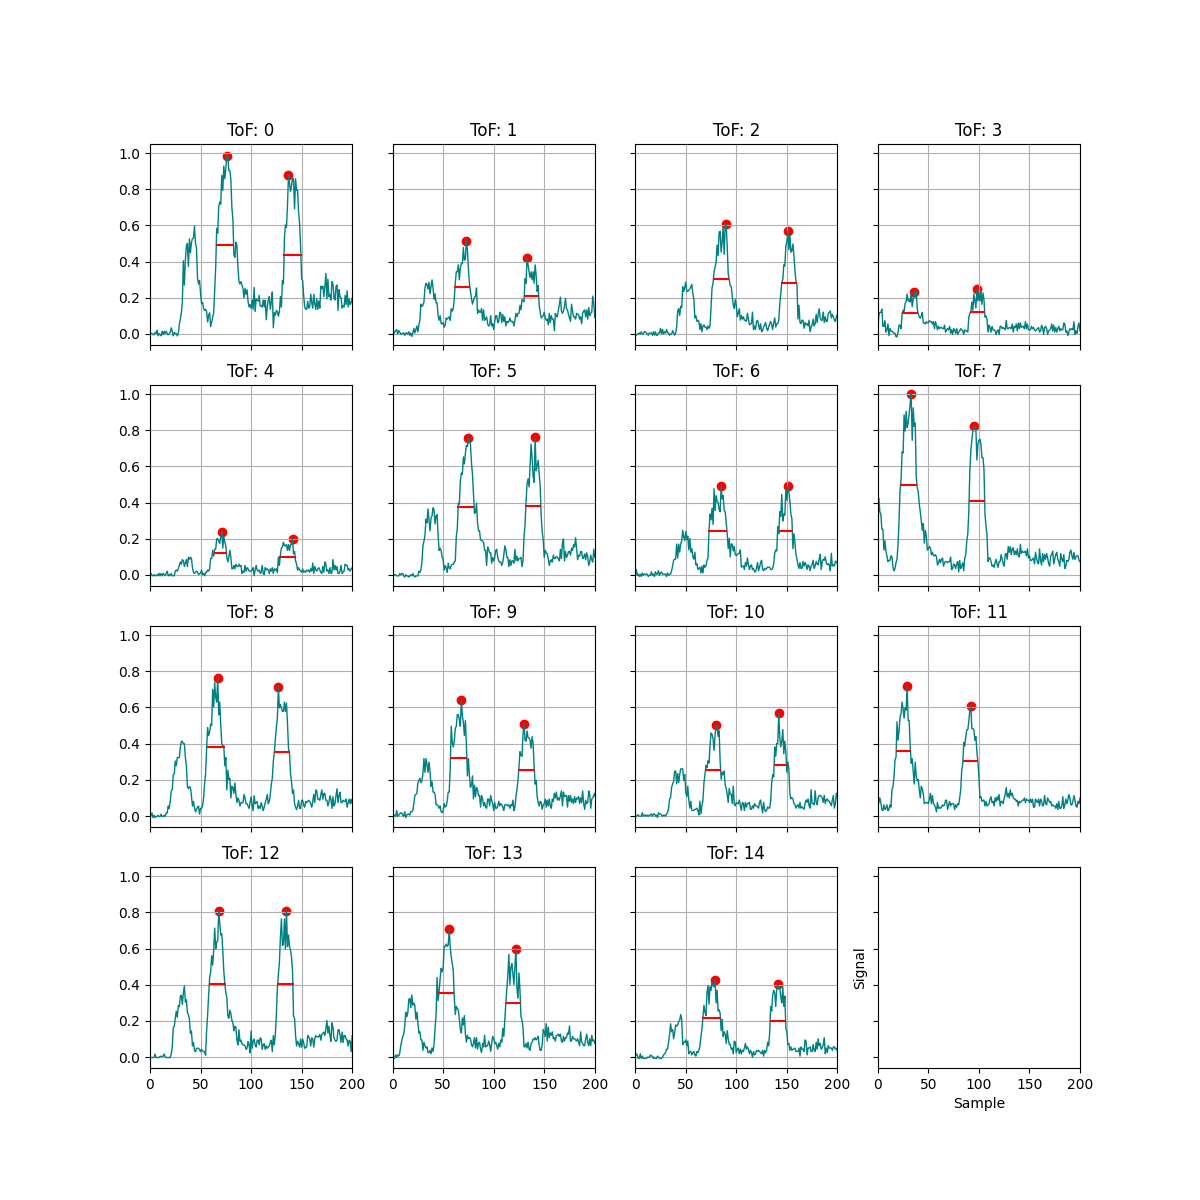

In [71]:
%matplotlib widget
results = ToFPipeline.PeakFinder(data.data).stack().normalize().process(threshold=0.01,peakNo=1,roi=[0,200],minWidth=False,symmetric=False).dataframe().plot(logScale=False,xmin=0,xmax=200)

In [72]:
ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
import pandas as pd
setPhotonEnergy = [1300]
runs = runNo
setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
runsPhotonEnergy = pd.DataFrame(setEnergyRun)
merge = pd.merge(data.data["trainId"].to_dataframe(),runsPhotonEnergy, on="daq_run", how="left")
merge=merge[merge["pulseId"]==0]
trim=merge[["trainId","daq_run","Photon Energy"]]
trim = trim.loc[:,~trim.columns.duplicated()]
ToFPipeline.AuxFunc(results.results).addData(trim)


In [141]:
importlib.reload(ToFPipeline)
ToFPipeline.GlobalConfig.load("config.yaml")

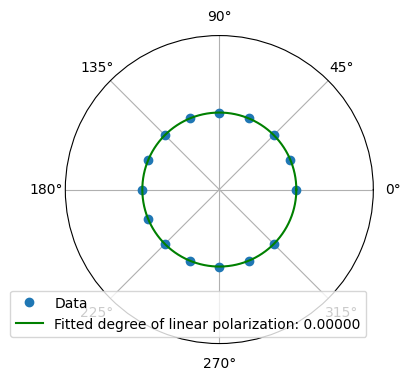

(array([5.96062831e-11, 6.19345241e-02, 1.00000000e+00]),
 array([[2.96075717e-22, 0.00000000e+00, 1.21257643e-23],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [1.21257643e-23, 0.00000000e+00, 1.50457900e-22]]))

In [142]:
beta=2
calib = ToFPipeline.Calibrate(results.results).transmission(peakNo=1,setBeta=beta,setPlin=0.00,setPhi=0).transmissionParam
ToFPipeline.Plotter(results.results).plotPol(calib,peakNo=1,beta=beta)

In [143]:
#importlib.reload(ToFPipeline)
#ToFPipeline.GlobalConfig.load("config.yaml")

Random trainId: 2119, pulseId: 0


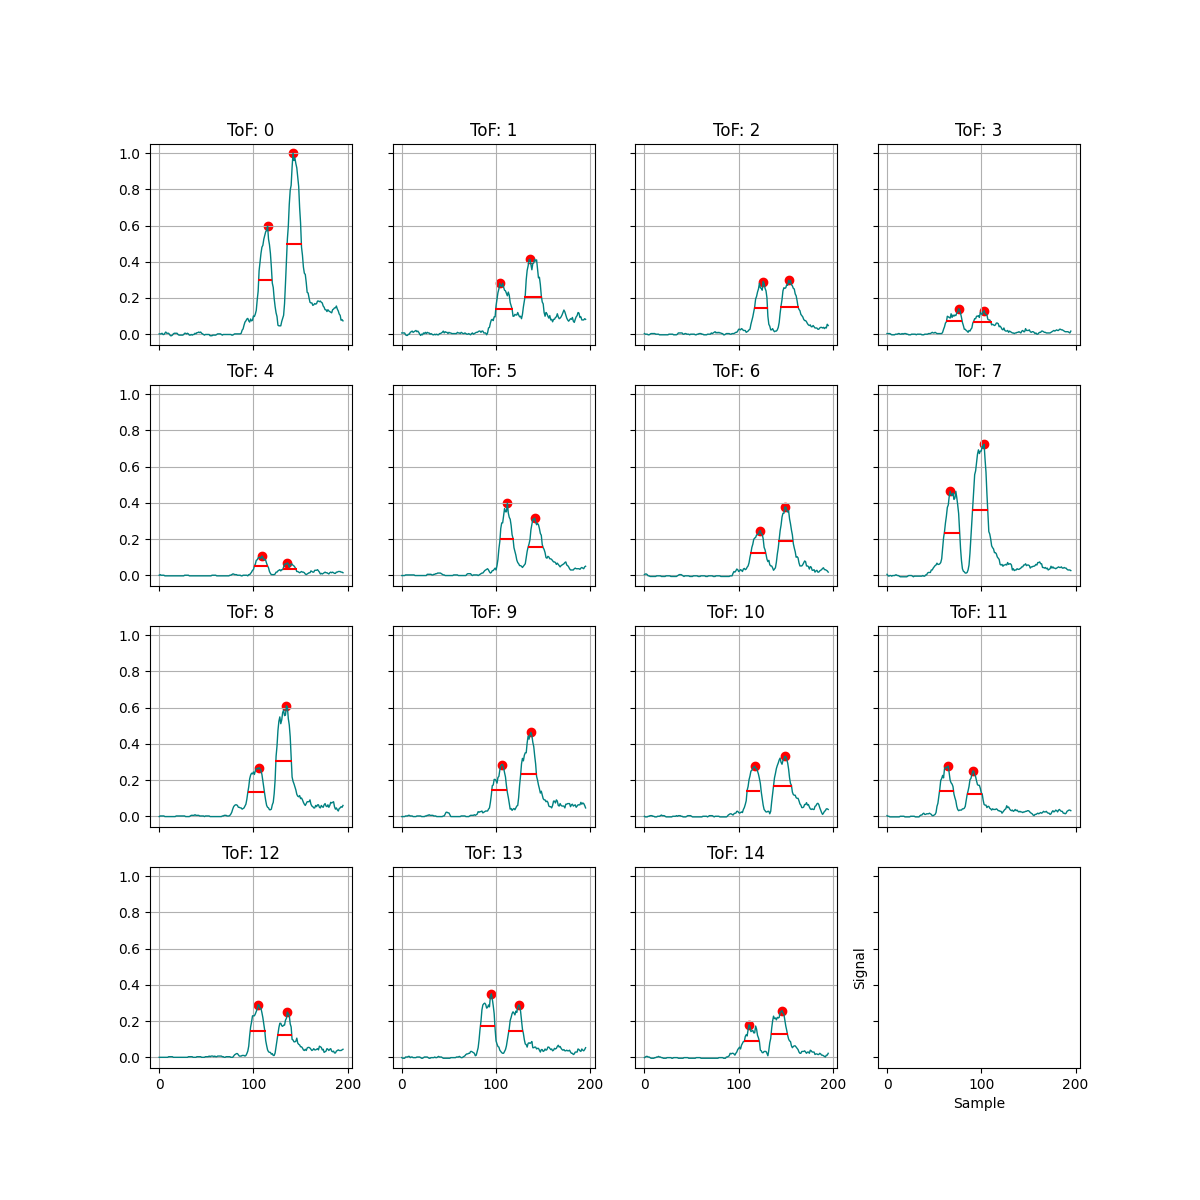

In [144]:
%matplotlib widget
data = ToFPipeline.NXSLoader("data").load(runNumbers=[2119],roi=[200,400]).defaultPreprocessing(baselineRegion=[0,10])
results = ToFPipeline.PeakFinder(data.data).stack().smooth(windowSize=5).normalize().process(threshold=0.01,peakNo=1,roi=[None,400],minWidth=False,symmetric=False).dataframe().plot(logScale=False,xmin=None,xmax=None)

In [151]:
import pandas as pd
from io import StringIO
rawdf = pd.read_csv(StringIO(raw), sep="|", skiprows=1).dropna().astype({"Photon Energy":int,"daq_run":int,"Ugap":float,"Ushift":float})
rawdf = rawdf[["daq_run","Photon Energy","Ugap","Ushift"]]
rawdf

,daq_run,Photon Energy,Ugap,Ushift
0,2119,1300,29.673,14.0
1,2120,1300,28.224,17.0
2,2121,1300,26.669,20.0
3,2122,1300,25.169,23.0
4,2123,1290,29.575,14.0
...,...,...,...,...
123,2243,1010,22.522,23.0
124,2244,1000,26.481,14.0
125,2245,1000,25.146,17.0
126,2246,1000,23.745,20.0


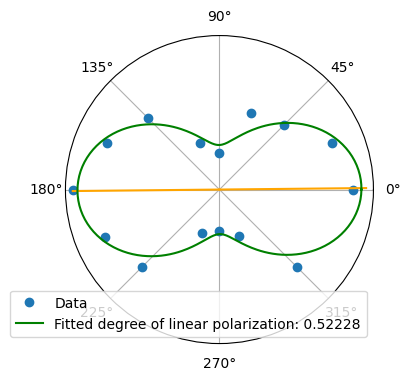

Completed run 2119


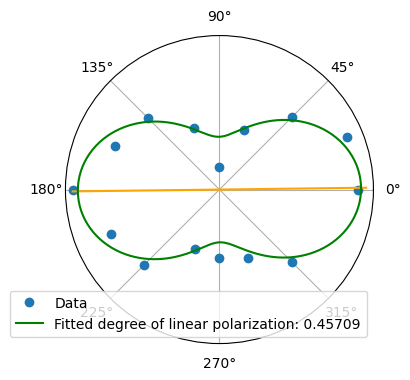

Completed run 2120


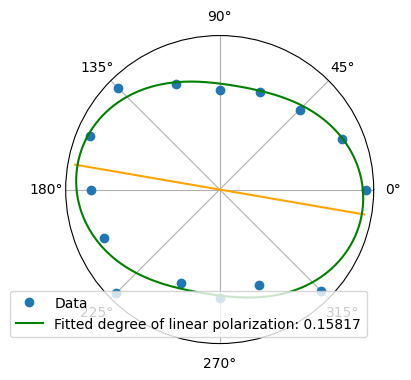

Completed run 2121


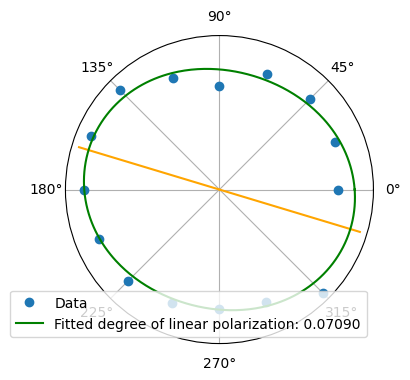

Completed run 2122


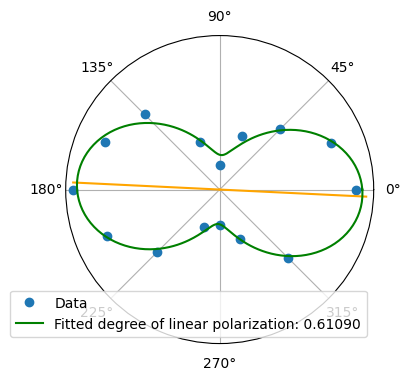

Completed run 2123


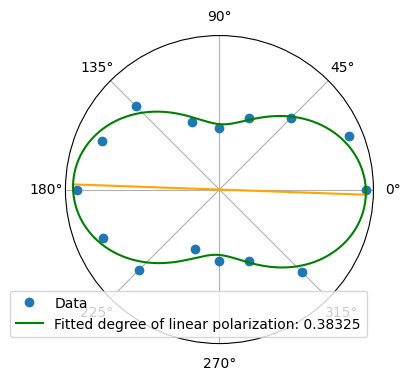

Completed run 2124


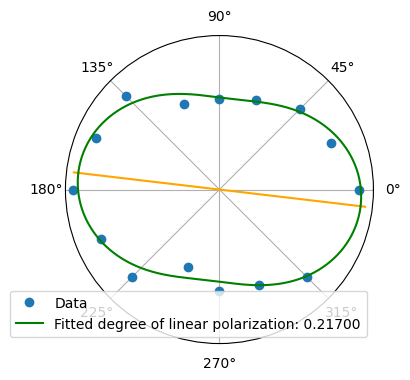

Completed run 2125


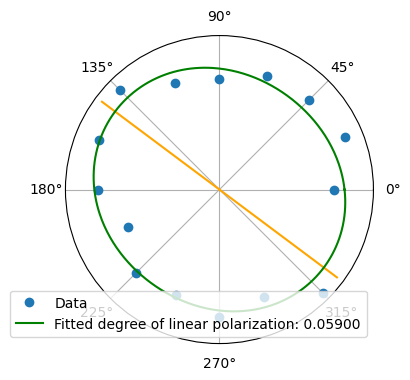

Completed run 2126


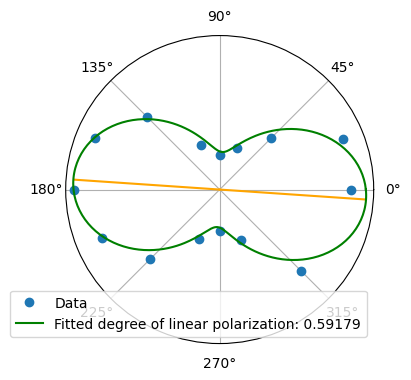

Completed run 2127


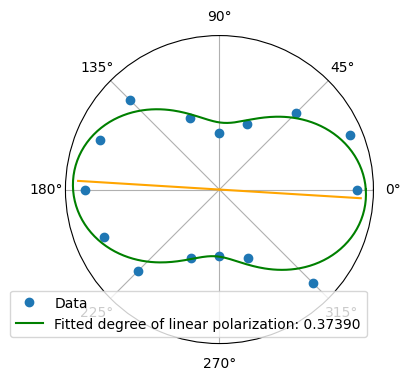

Completed run 2128


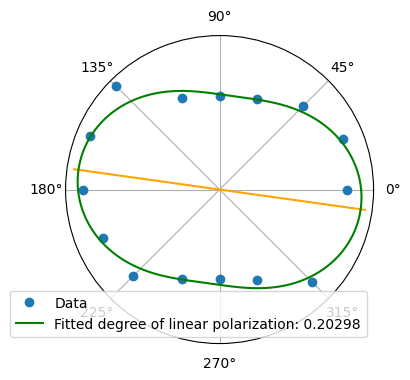

Completed run 2129


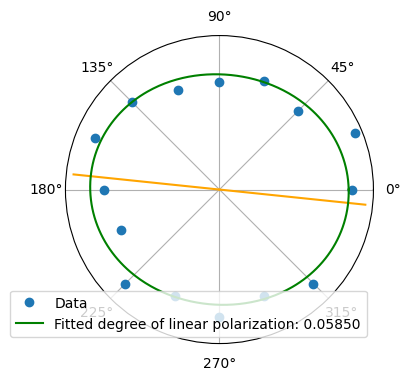

Completed run 2130


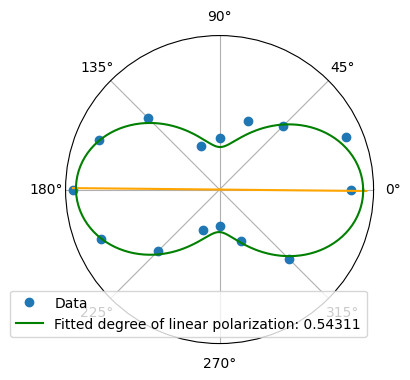

Completed run 2131


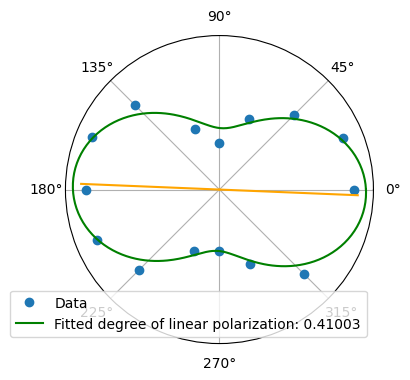

Completed run 2132


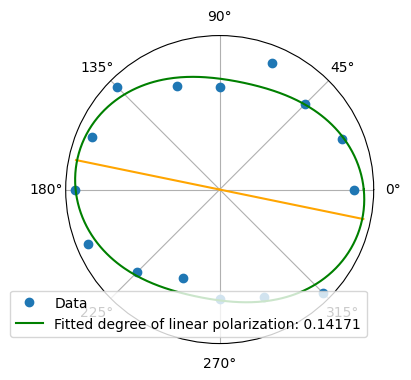

Completed run 2133


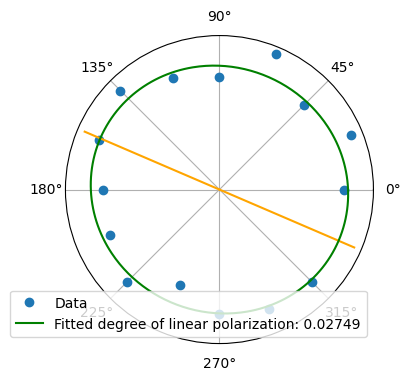

Completed run 2134


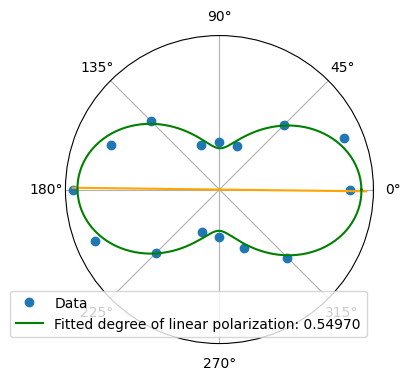

Completed run 2135


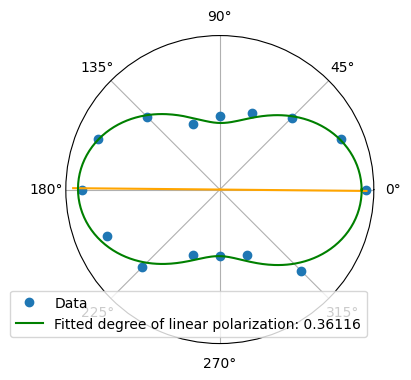

Completed run 2136


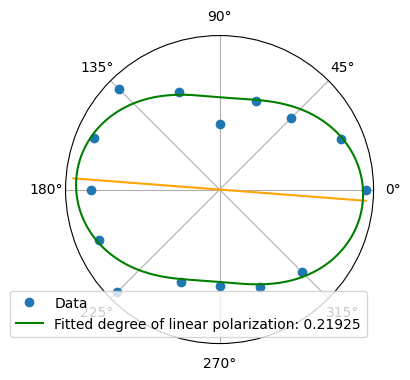

Completed run 2137


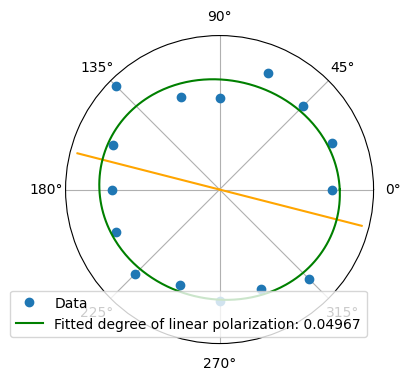

Completed run 2138


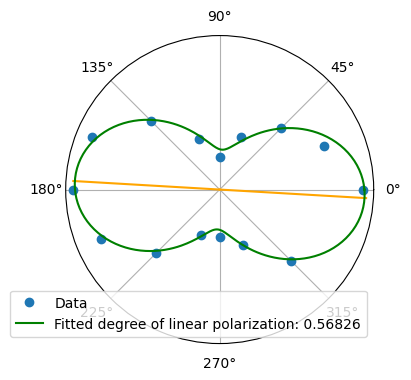

Completed run 2139


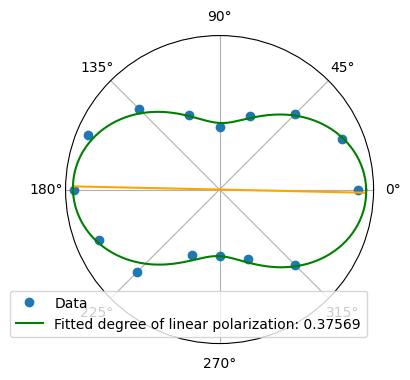

Completed run 2140


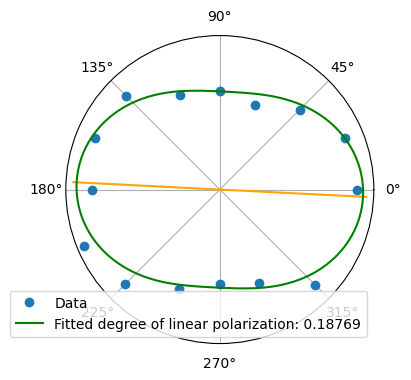

Completed run 2141


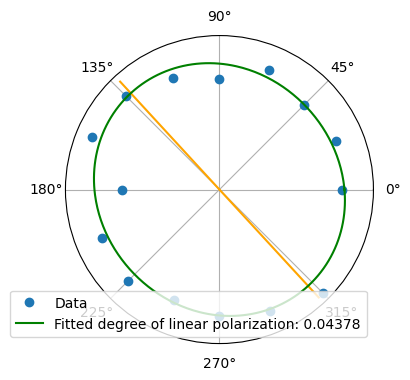

Completed run 2142


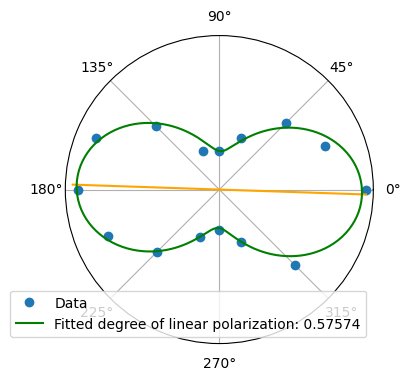

Completed run 2143


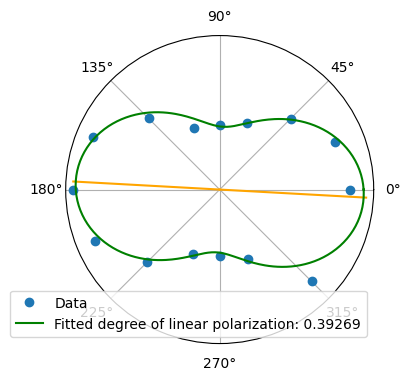

Completed run 2144


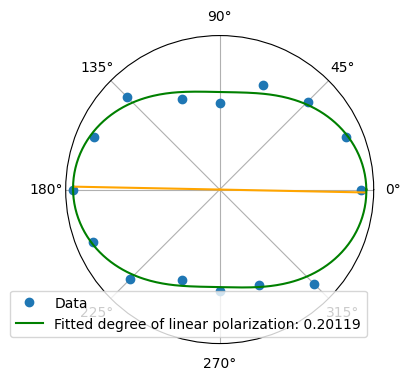

Completed run 2145


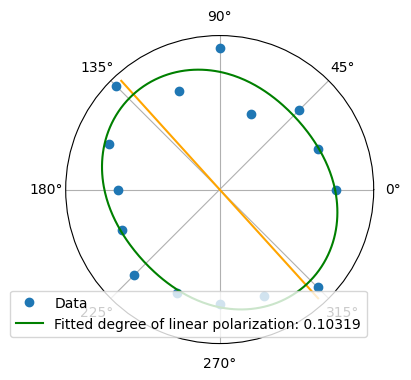

Completed run 2146


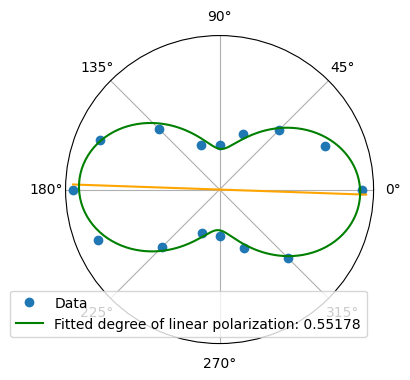

Completed run 2147


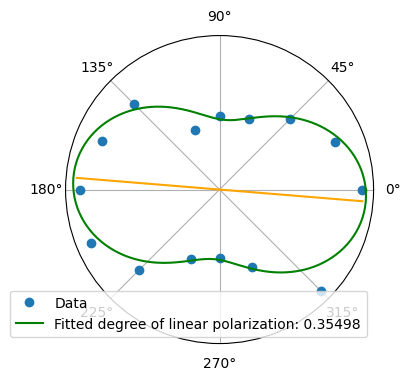

Completed run 2148


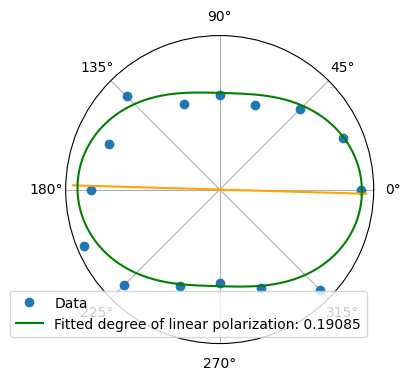

Completed run 2149


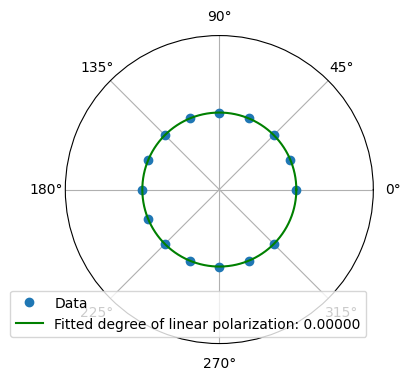

Completed run 2150


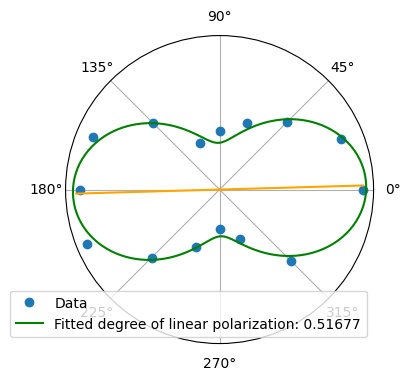

Completed run 2152


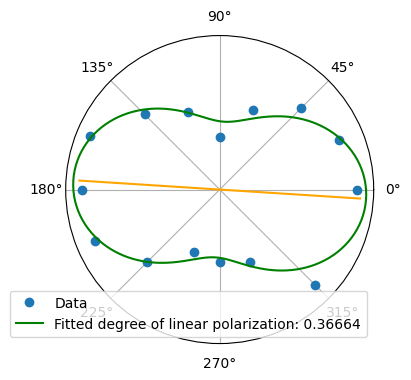

Completed run 2153


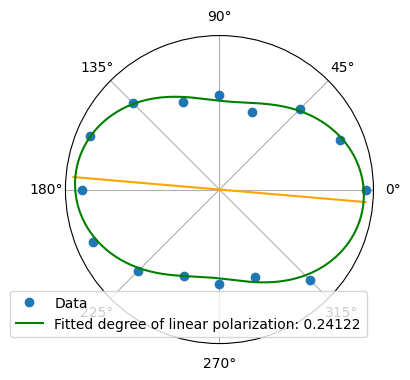

Completed run 2154


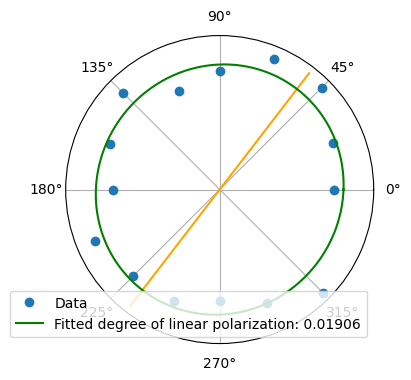

Completed run 2155


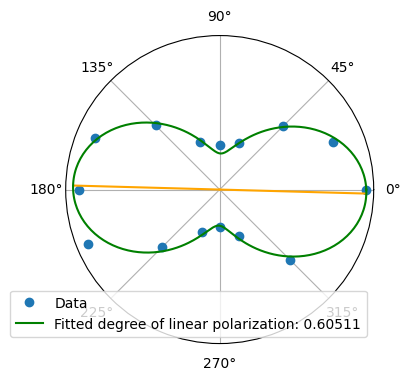

Completed run 2156


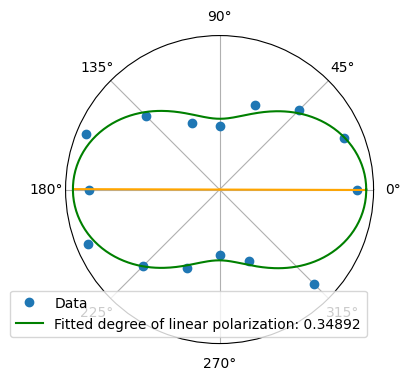

Completed run 2157


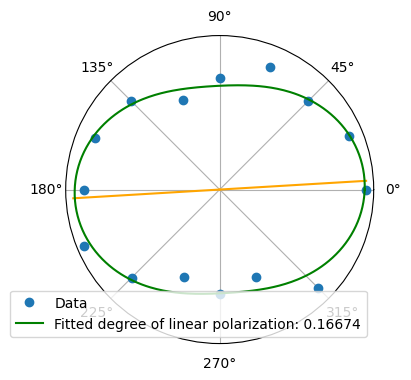

Completed run 2158


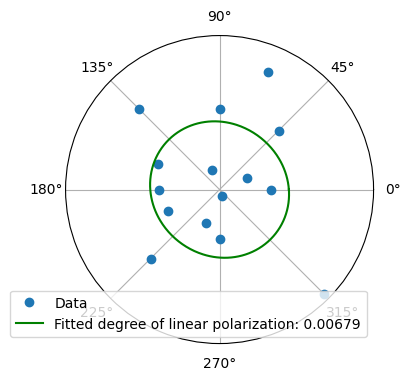

Completed run 2159


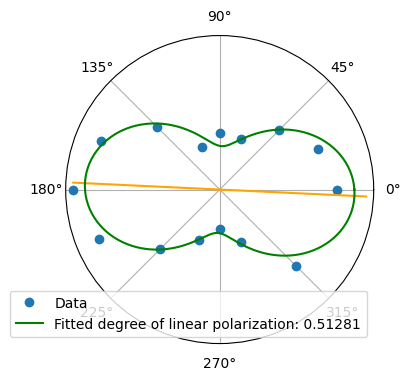

Completed run 2160


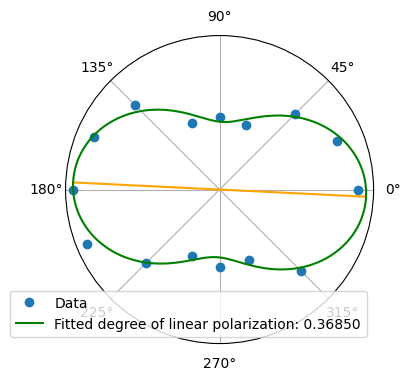

Completed run 2161


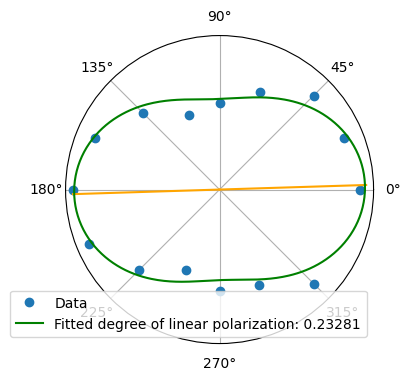

Completed run 2162


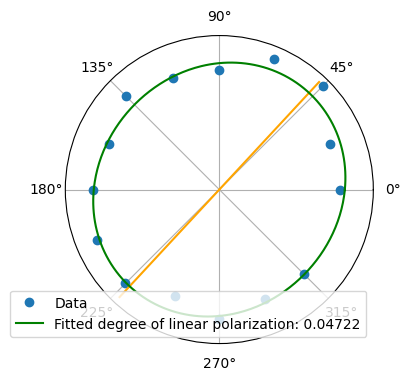

Completed run 2163


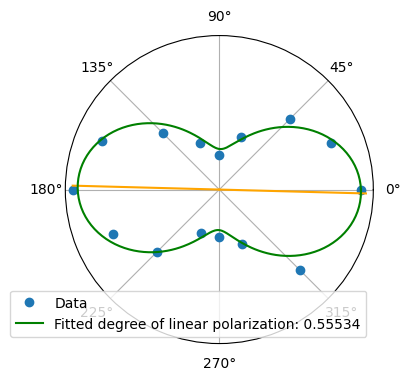

Completed run 2164


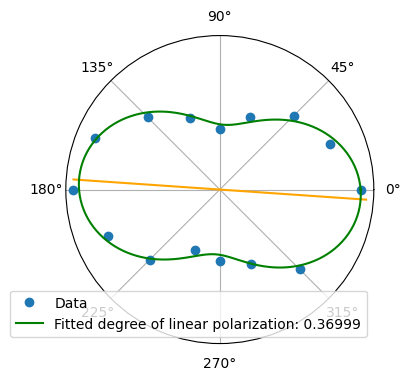

Completed run 2165


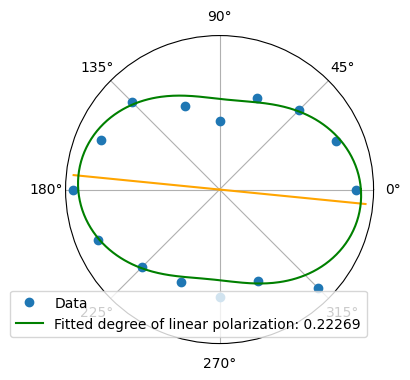

Completed run 2166


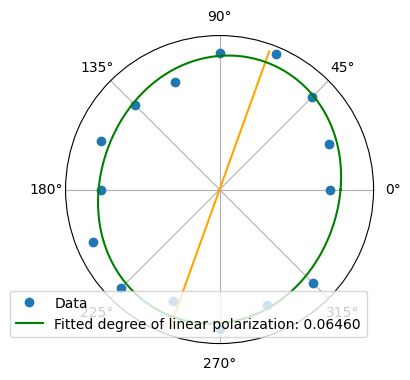

Completed run 2167


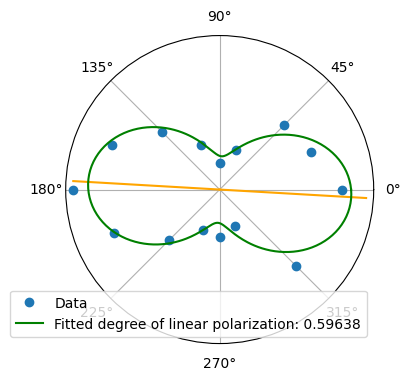

Completed run 2168


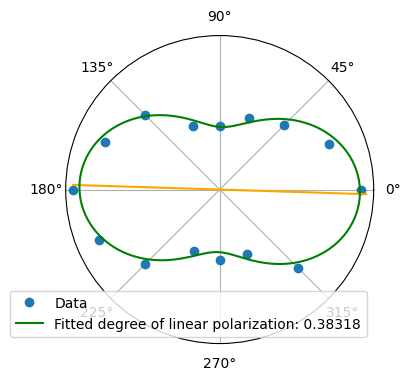

Completed run 2169


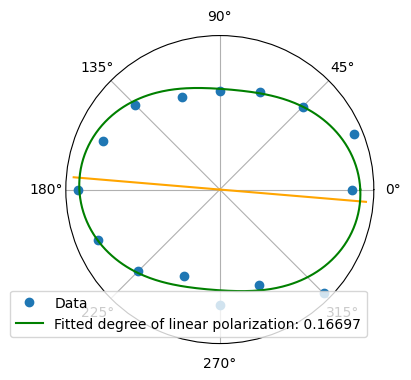

Completed run 2170


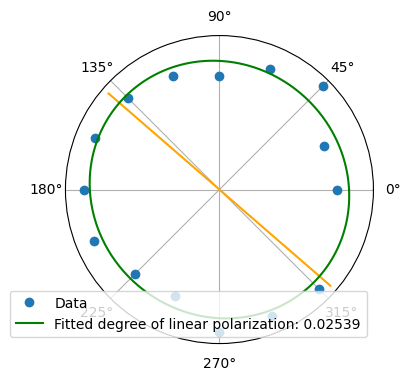

Completed run 2171


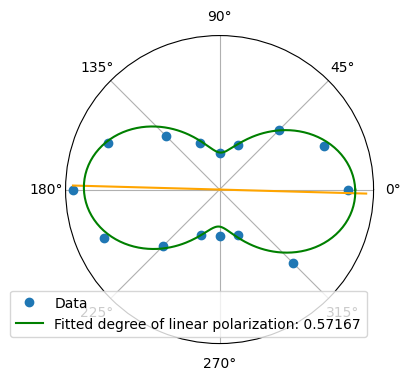

Completed run 2172


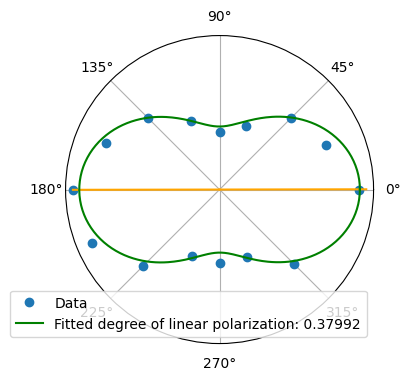

Completed run 2173


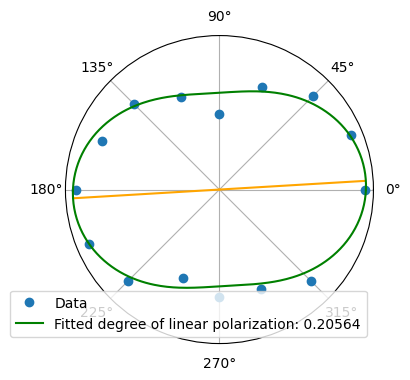

Completed run 2174


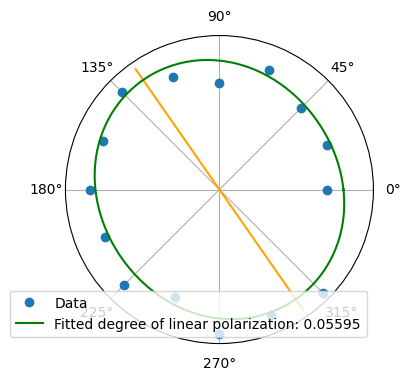

Completed run 2175


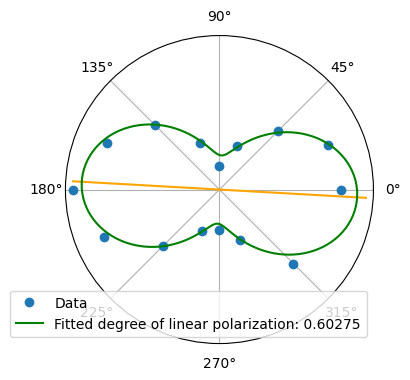

Completed run 2176


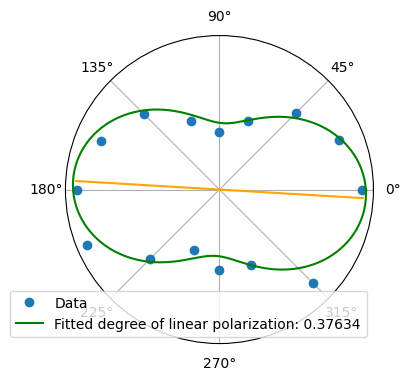

Completed run 2177


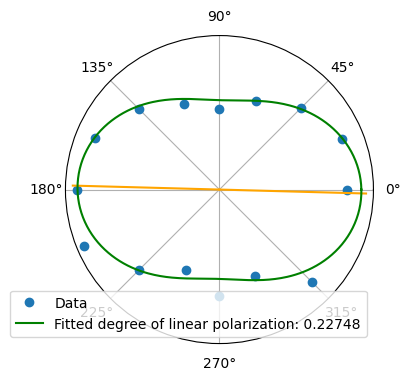

Completed run 2178


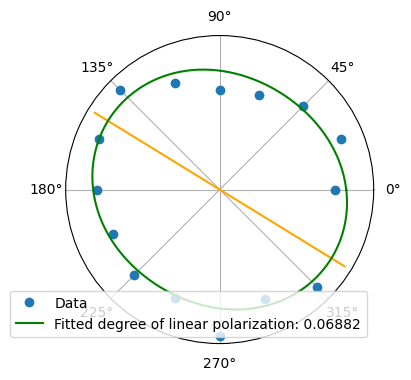

Completed run 2179


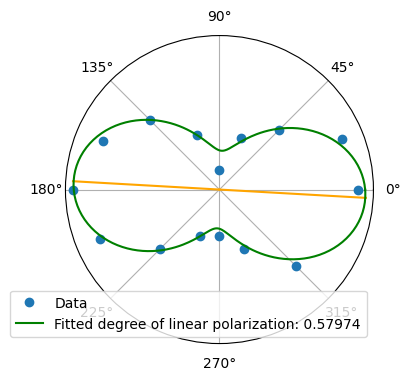

Completed run 2180


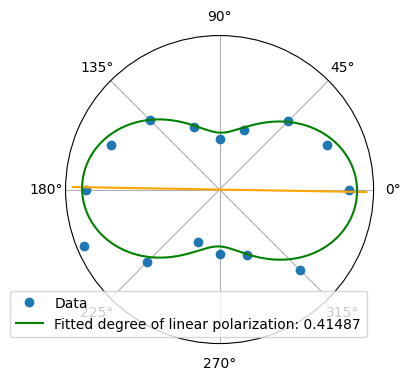

Completed run 2181


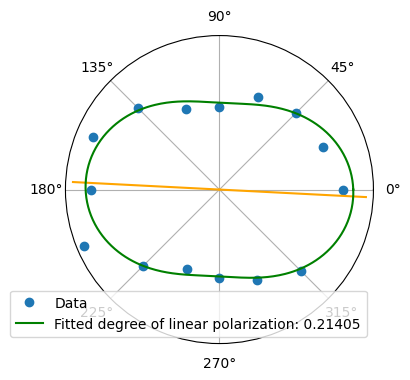

Completed run 2182


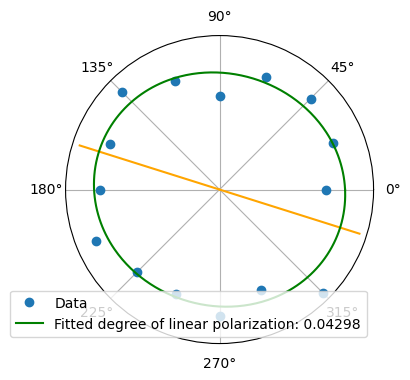

Completed run 2183


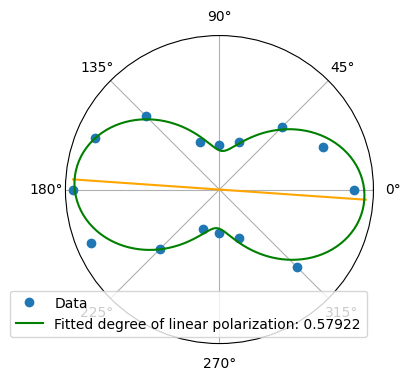

Completed run 2184


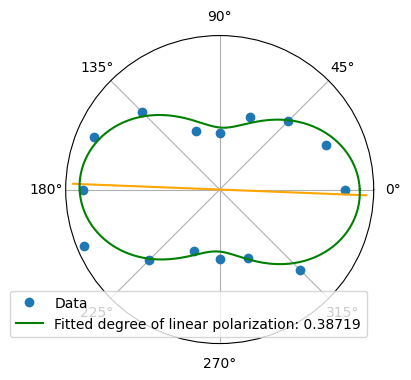

Completed run 2185


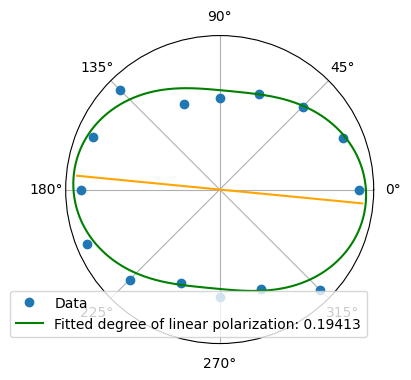

Completed run 2186


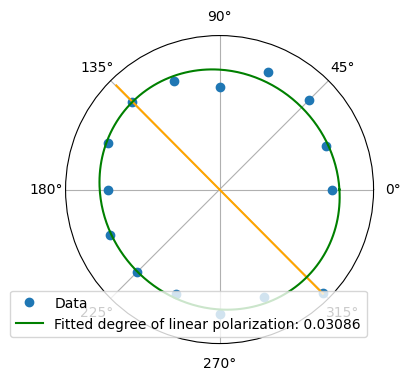

Completed run 2187


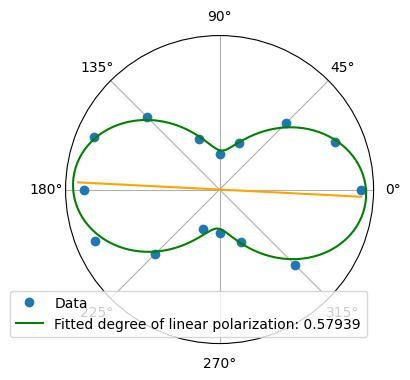

Completed run 2188


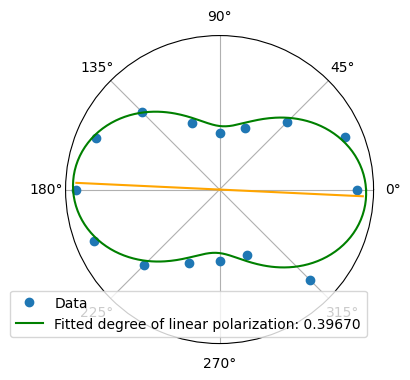

Completed run 2189


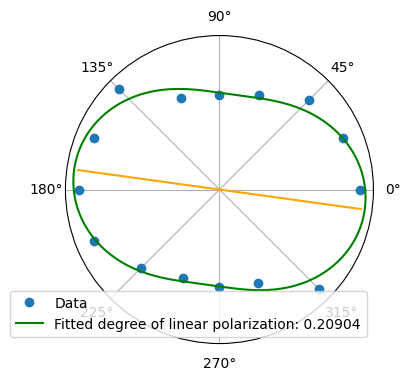

Completed run 2190


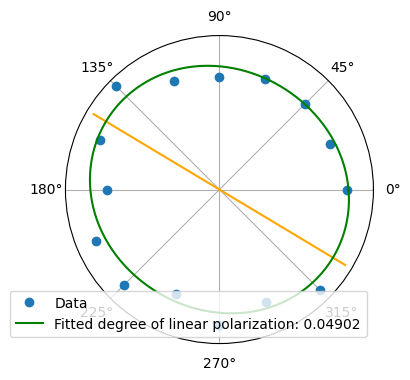

Completed run 2191


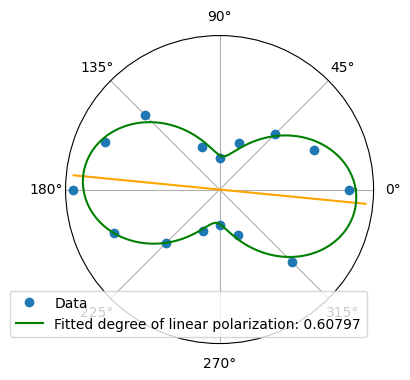

Completed run 2192


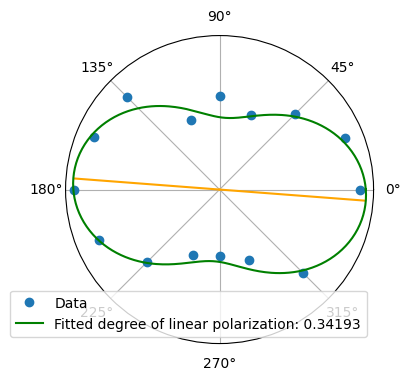

Completed run 2193


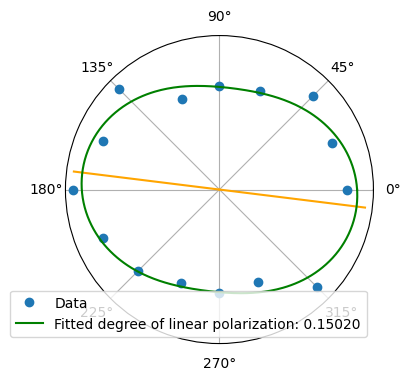

Completed run 2194


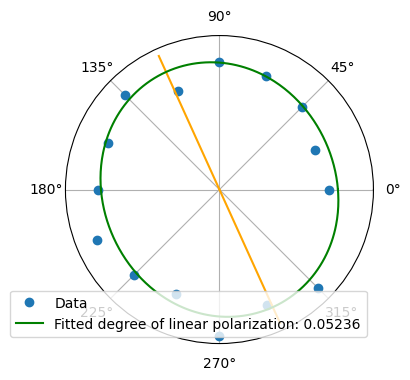

Completed run 2195


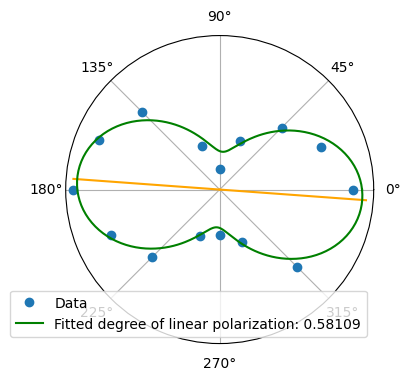

Completed run 2196


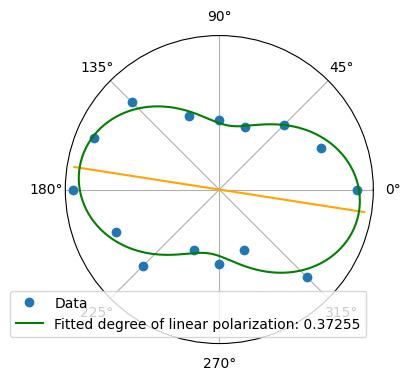

Completed run 2197


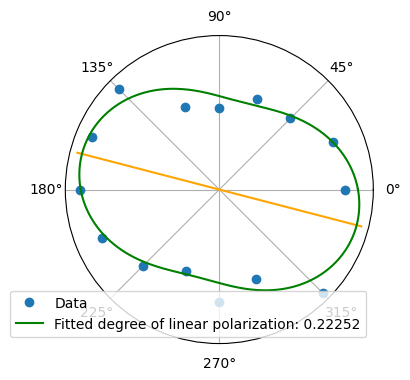

Completed run 2198


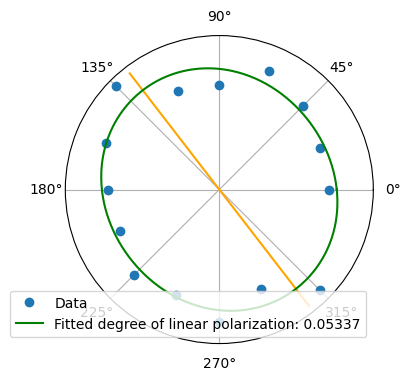

Completed run 2199


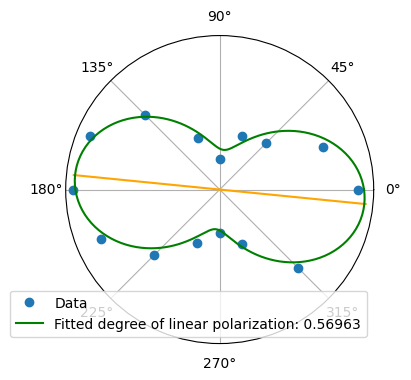

Completed run 2200


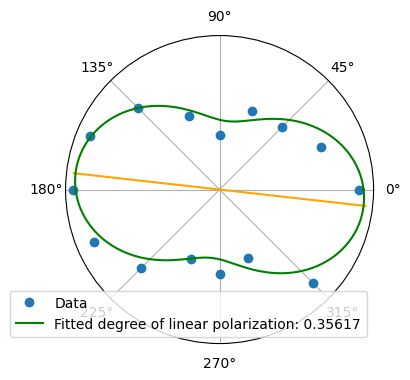

Completed run 2201


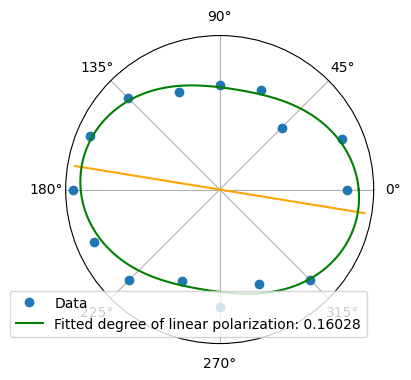

Completed run 2202


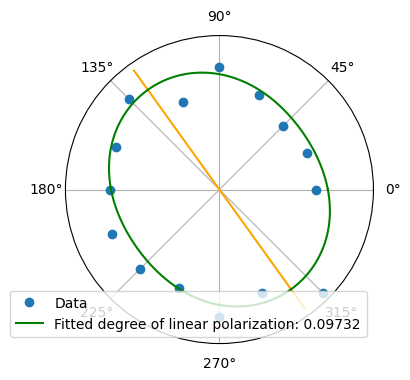

Completed run 2203


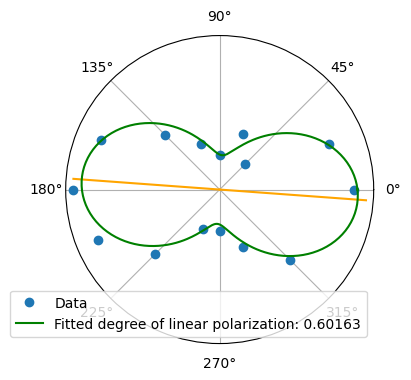

Completed run 2204


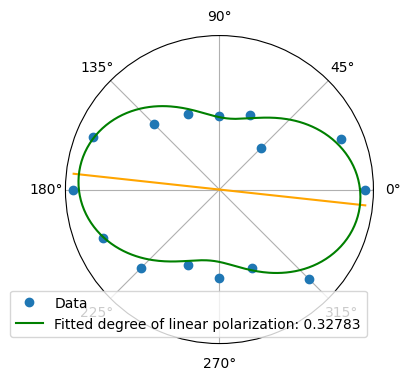

Completed run 2205


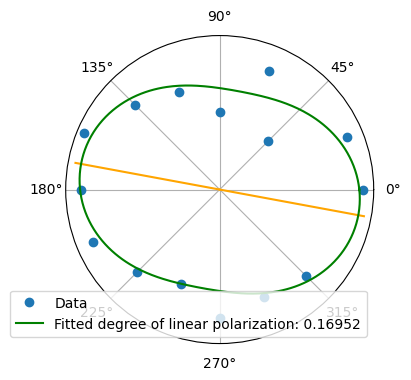

Completed run 2206


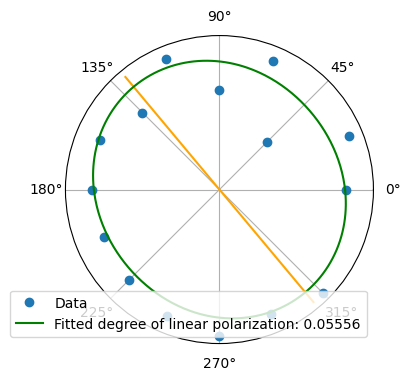

Completed run 2207


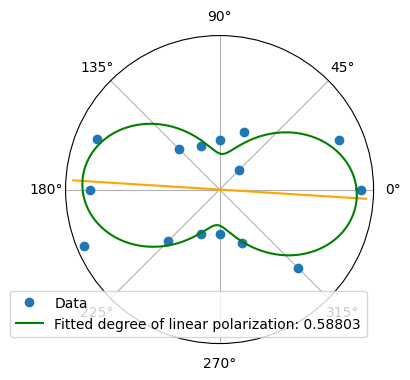

Completed run 2208


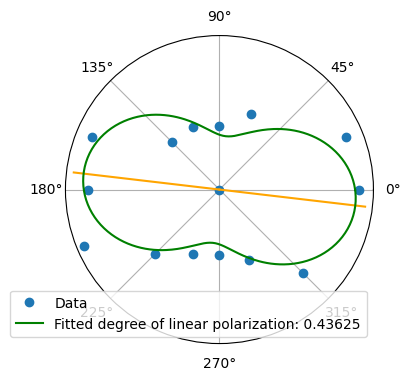

Completed run 2209


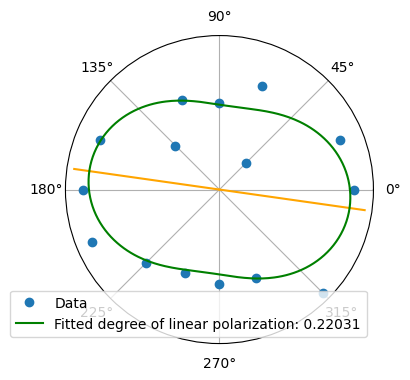

Completed run 2210


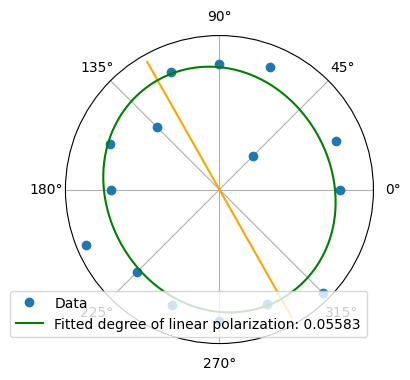

Completed run 2211


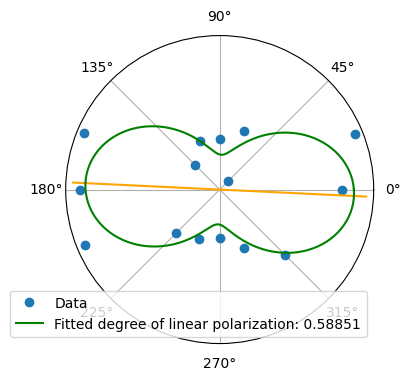

Completed run 2212


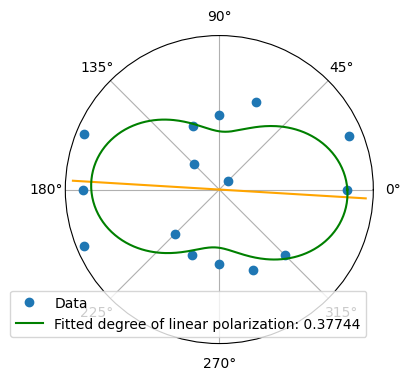

Completed run 2213


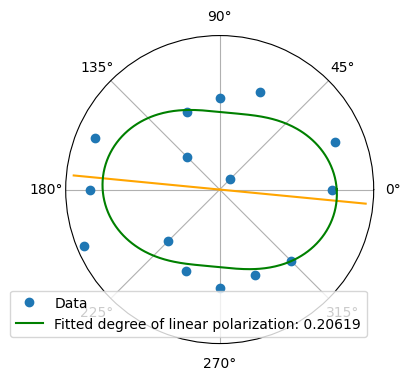

Completed run 2214


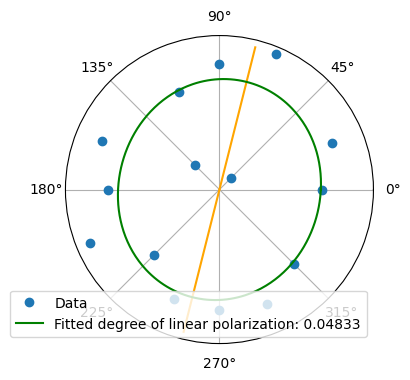

Completed run 2215


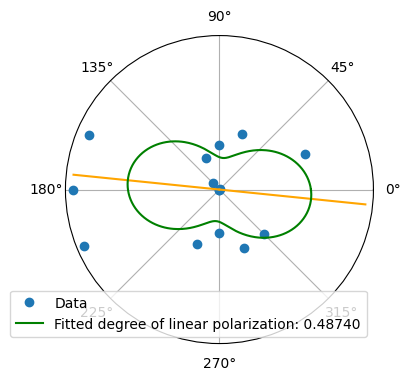

Completed run 2216


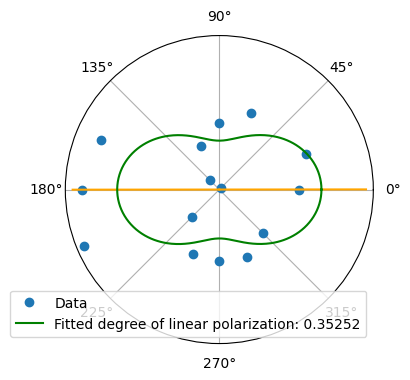

Completed run 2217


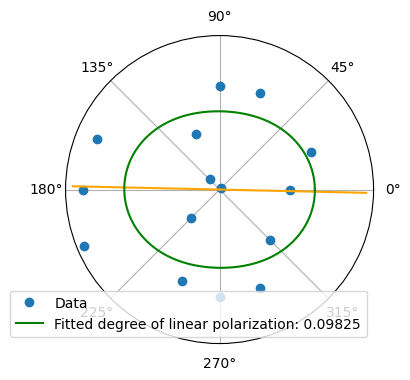

Completed run 2218


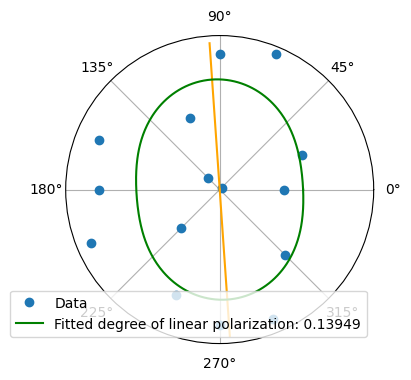

Completed run 2219


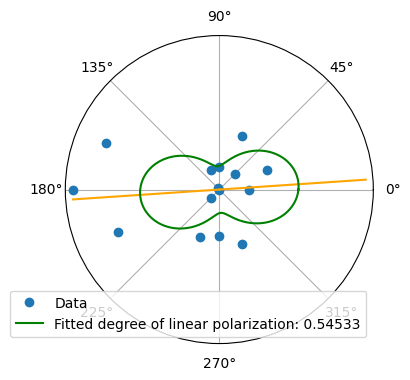

Completed run 2220


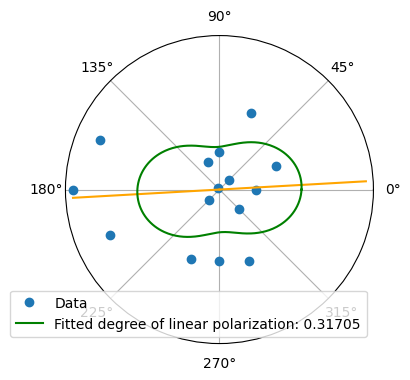

Completed run 2221


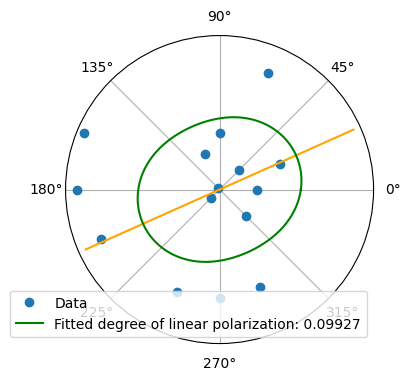

Completed run 2222


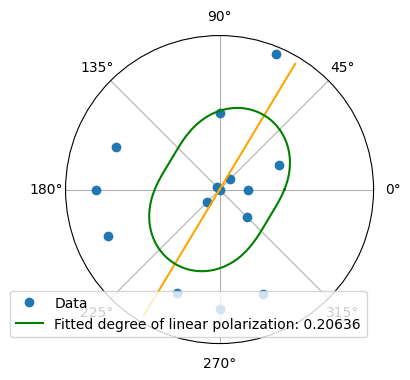

Completed run 2223


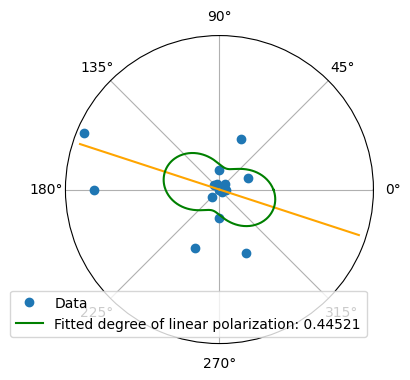

Completed run 2224


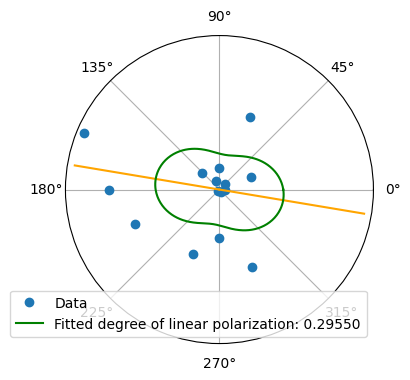

Completed run 2225


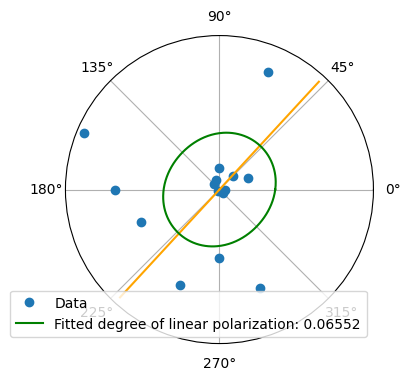

Completed run 2226


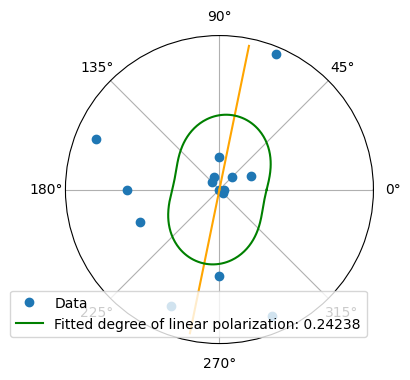

Completed run 2227


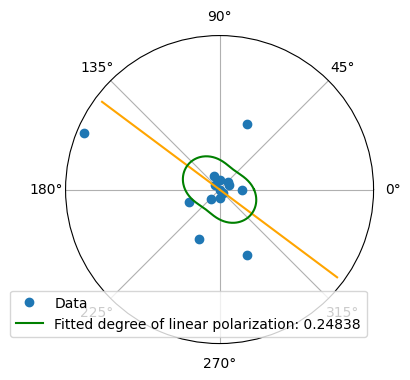

Completed run 2228


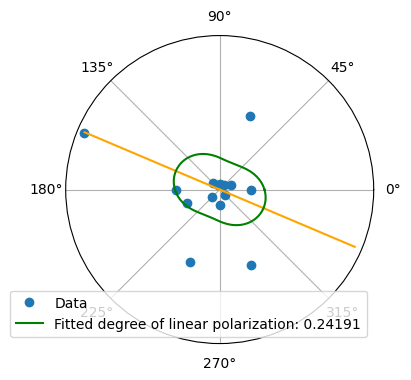

Completed run 2229


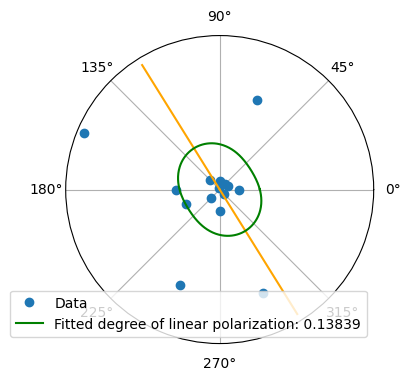

Completed run 2230


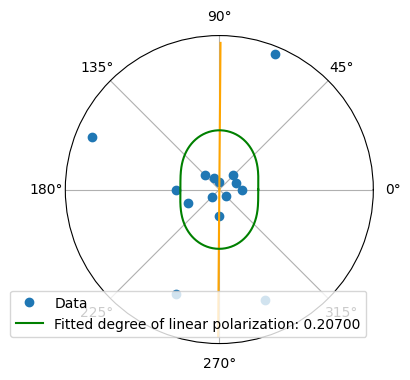

Completed run 2231


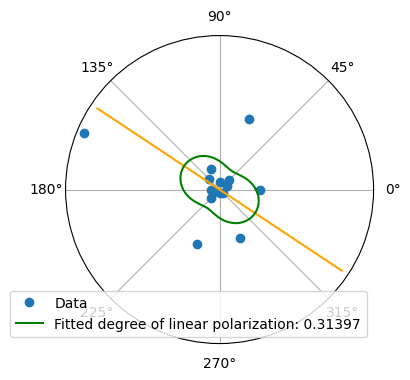

Completed run 2232


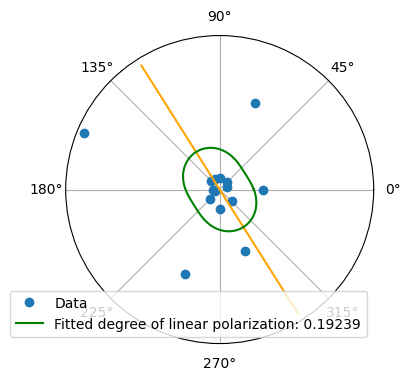

Completed run 2233


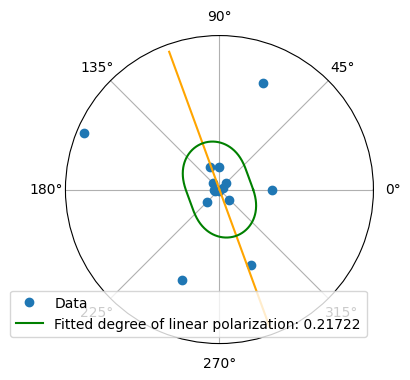

Completed run 2234


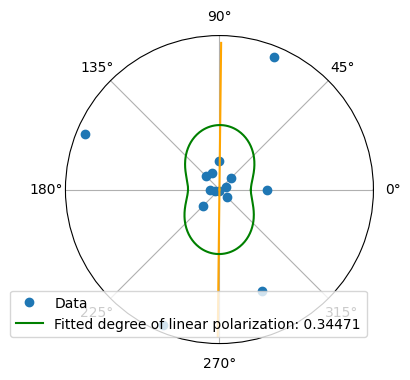

Completed run 2235


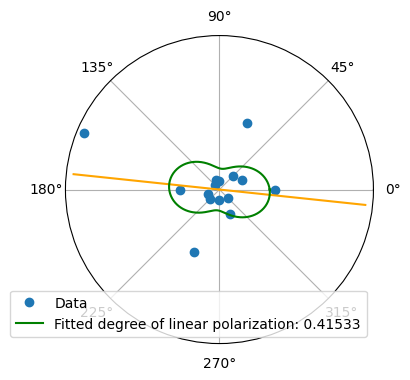

Completed run 2236


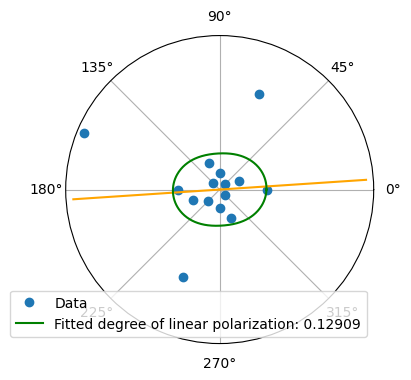

Completed run 2237


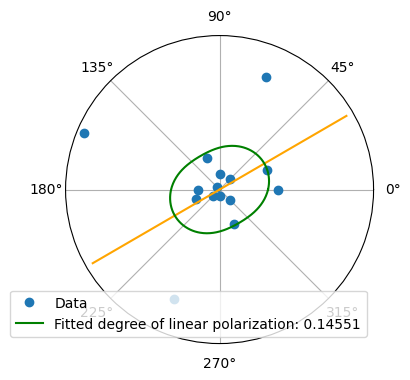

Completed run 2238


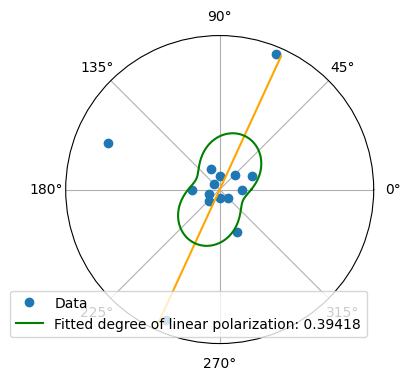

Completed run 2239


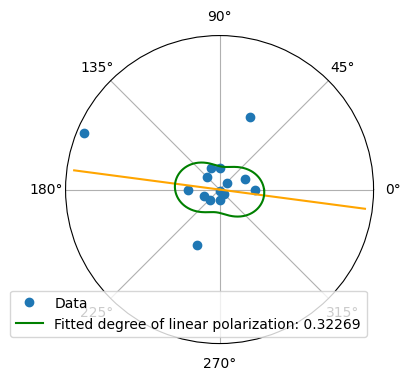

Completed run 2240


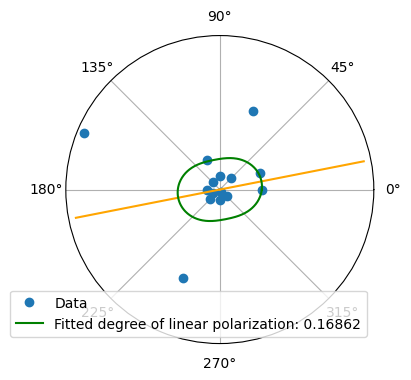

Completed run 2241


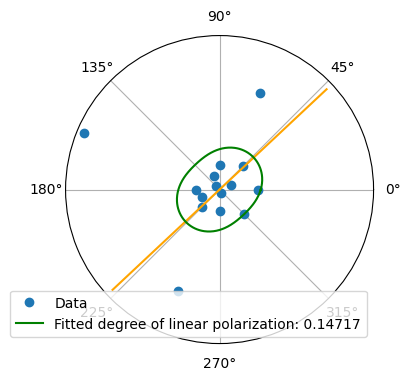

Completed run 2242


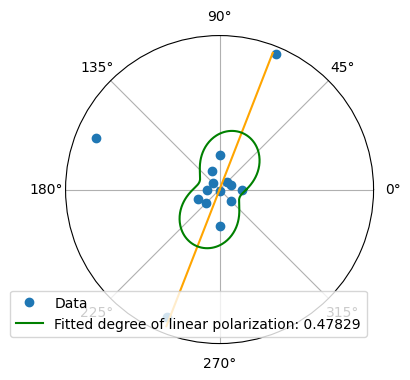

Completed run 2243


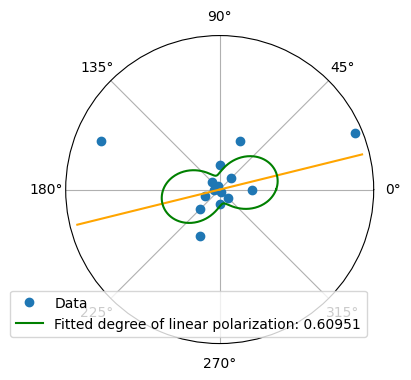

Completed run 2244


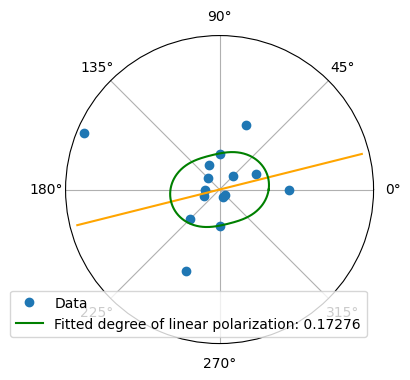

Completed run 2245


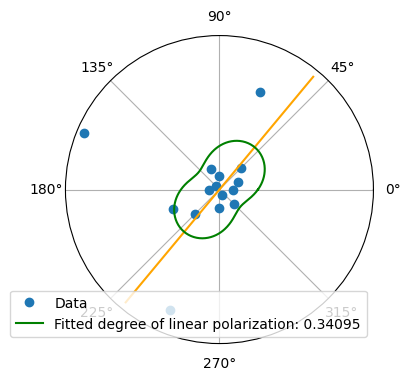

Completed run 2246


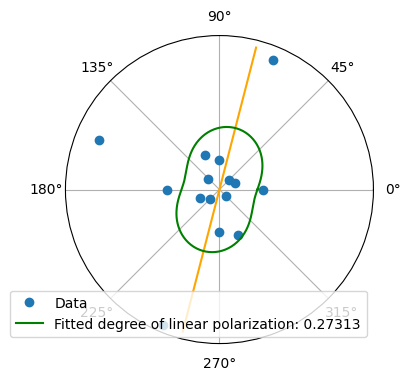

Completed run 2247


In [152]:
%matplotlib inline
values=[]
energies=[]
daq_run=[]
for i in rawdf["daq_run"].unique():
    runNo = i
    setPhotonEnergy = rawdf[rawdf["daq_run"]==runNo]["Photon Energy"].values
    data = ToFPipeline.NXSLoader("data").load(runNumbers=[runNo],roi=[200,400]).defaultPreprocessing(baselineRegion=[0,10],ToF=list(range(15)))
    results = ToFPipeline.PeakFinder(data.data).stack().smooth(windowSize=5).normalize().process(threshold=0.01,peakNo=1,roi=[None,400],minWidth=False,symmetric=False).dataframe()#.plot(logScale=False,xmin=None,xmax=None)
    ToFPipeline.AuxFunc(results.results).addData(data.angles, key="Angles", axis="detector")
    runs = runNo
    setEnergyRun = {"daq_run": runs, "Photon Energy": setPhotonEnergy}
    runsPhotonEnergy = pd.DataFrame(setEnergyRun)
    merge = pd.merge(data.data["trainId"].to_dataframe(),runsPhotonEnergy, on="daq_run", how="left")
    merge=merge[merge["pulseId"]==0]
    trim=merge[["trainId","daq_run","Photon Energy"]]
    trim = trim.loc[:,~trim.columns.duplicated()]
    ToFPipeline.AuxFunc(results.results).addData(trim)
    popt,pcov = ToFPipeline.Plotter(results.results).plotPol(calib,peakNo=1,beta=2)
    values.append(popt)
    energies.append(setPhotonEnergy[0])
    daq_run.append(runNo)
    print(f"Completed run {runNo}")
values=pd.DataFrame(values, columns=["PLin","phi","scale"])
values["Photon Energy"]=energies
values["daq_run"]=daq_run


In [153]:
raw = """
> |Photon Energy|daq_run|Ugap|Ushift
> |1300|2119|29.673|14
> |1300|2120|28.224|17
> |1300|2121|26.669|20
> |1300|2122|25.169|23
> |1290|2123|29.575|14
> |1290|2124|28.13|17
> |1290|2125|26.579|20
> |1290|2126|25.083|23
> |1280|2127|29.478|14
> |1280|2128|28.034|17
> |1280|2129|26.489|20
> |1280|2130|24.999|23
> |1270|2131|29.378|14
> |1270|2132|27.938|17
> |1270|2133|26.399|20
> |1270|2134|24.913|23
> |1260|2135|29.28|14
> |1260|2136|27.843|17
> |1260|2137|26.308|20
> |1260|2138|24.827|23
> |1250|2139|29.179|14
> |1250|2140|27.747|17
> |1250|2141|26.216|20
> |1250|2142|24.741|23
> |1240|2143|29.079|14
> |1240|2144|27.649|17
> |1240|2145|26.124|20
> |1240|2146|24.655|23
> |1230|2147|28.979|14
> |1230|2148|27.552|17
> |1230|2149|26.03|20
> |1230|2150|24.567|23
> |1230|2152|28.979|14
> |1230|2153|27.552|17
> |1230|2154|26.03|20
> |1230|2155|24.567|23
> |1220|2156|28.878|14
> |1220|2157|27.454|17
> |1220|2158|25.938|20
> |1220|2159|24.479|23
> |1210|2160|28.776|14
> |1210|2161|27.356|17
> |1210|2162|25.845|20
> |1210|2163|24.392|23
> |1200|2164|28.673|14
> |1200|2165|27.257|17
> |1200|2166|25.751|20
> |1200|2167|24.304|23
> |1190|2168|28.569|14
> |1190|2169|27.157|17
> |1190|2170|25.655|20
> |1190|2171|24.216|23
> |1180|2172|28.466|14
> |1180|2173|27.058|17
> |1180|2174|25.56|20
> |1180|2175|24.126|23
> |1170|2176|28.362|14
> |1170|2177|26.956|17
> |1170|2178|25.464|20
> |1170|2179|24.036|23
> |1160|2180|28.257|14
> |1160|2181|26.854|17
> |1160|2182|25.368|20
> |1160|2183|23.946|23
> |1150|2184|28.151|14
> |1150|2185|26.753|17
> |1150|2186|25.271|20
> |1150|2187|23.854|23
> |1140|2188|28.046|14
> |1140|2189|26.651|17
> |1140|2190|25.175|20
> |1140|2191|23.763|23
> |1130|2192|27.938|14
> |1130|2193|26.548|17
> |1130|2194|25.075|20
> |1130|2195|23.671|23
> |1120|2196|27.831|14
> |1120|2197|26.444|17
> |1120|2198|24.978|20
> |1120|2199|23.579|23
> |1110|2200|27.722|14
> |1110|2201|26.341|17
> |1110|2202|24.878|20
> |1110|2203|23.485|23
> |1100|2204|27.614|14
> |1100|2205|26.235|17
> |1100|2206|24.778|20
> |1100|2207|23.392|23
> |1090|2208|27.503|14
> |1090|2209|26.13|17
> |1090|2210|24.679|20
> |1090|2211|23.298|23
> |1080|2212|27.394|14
> |1080|2213|26.022|17
> |1080|2214|24.577|20
> |1080|2215|23.204|23
> |1070|2216|27.282|14
> |1070|2217|25.915|17
> |1070|2218|24.476|20
> |1070|2219|23.108|23
> |1060|2220|27.171|14
> |1060|2221|25.808|17
> |1060|2222|24.374|20
> |1060|2223|23.013|23
> |1050|2224|27.058|14
> |1050|2225|25.7|17
> |1050|2226|24.271|20
> |1050|2227|22.915|23
> |1040|2228|26.944|14
> |1040|2229|25.591|17
> |1040|2230|24.167|20
> |1040|2231|22.819|23
> |1030|2232|26.829|14
> |1030|2233|25.479|17
> |1030|2234|24.062|20
> |1030|2235|22.72|23
> |1020|2236|26.714|14
> |1020|2237|25.37|17
> |1020|2238|23.958|20
> |1020|2239|22.622|23
> |1010|2240|26.599|14
> |1010|2241|25.257|17
> |1010|2242|23.851|20
> |1010|2243|22.522|23
> |1000|2244|26.481|14
> |1000|2245|25.146|17
> |1000|2246|23.745|20
> |1000|2247|22.423|23
"""

In [154]:
runTable = rawdf[["daq_run","Ugap","Ushift"]]
complete = values.merge(runTable, on="daq_run")

complete

,PLin,phi,scale,Photon Energy,daq_run,Ugap,Ushift
0,0.522280,0.010140,0.665170,1300,2119,29.673,14.0
1,0.457095,0.012591,0.683664,1300,2120,28.224,17.0
2,0.158170,-0.170521,0.960801,1300,2121,26.669,20.0
3,0.070899,-0.292976,1.074536,1300,2122,25.169,23.0
4,0.610895,-0.048175,0.701377,1290,2123,29.575,14.0
...,...,...,...,...,...,...,...
123,0.478290,1.199854,0.214602,1010,2243,22.522,23.0
124,0.609513,0.241936,0.281313,1000,2244,26.481,14.0
125,0.172761,0.245221,0.242257,1000,2245,25.146,17.0
126,0.340949,0.877209,0.203307,1000,2246,23.745,20.0


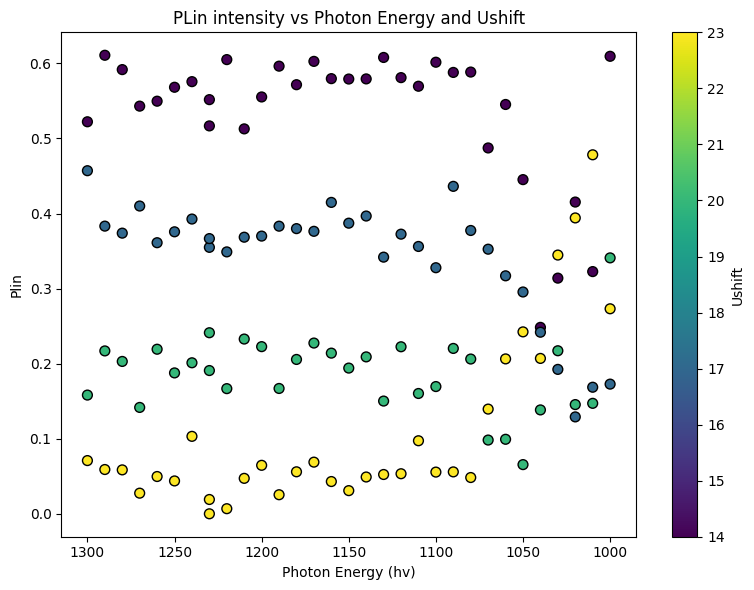

In [159]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ushift"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("Plin")
ax.set_title("PLin intensity vs Photon Energy and Ushift")
ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ushift")
plt.tight_layout()
plt.show()



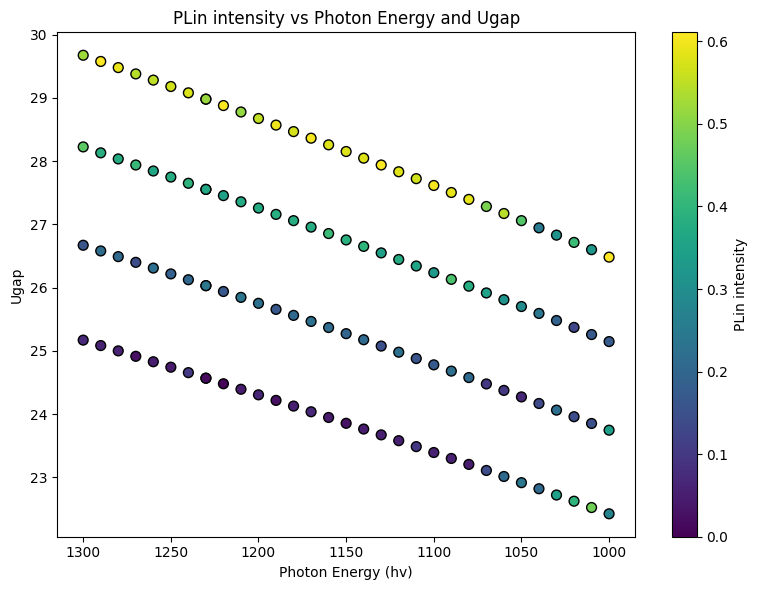

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(
    complete["Photon Energy"],          # x-axis
    complete["PLin"],      # y-axis
    c=complete["Ugap"],     # color = PL intensity
    cmap="viridis",    # choose any colormap
    s=50,              # marker size
    edgecolor="k"      # optional, black edge for clarity
)

ax.set_xlabel("Photon Energy (hv)")
ax.set_ylabel("PLin")
ax.set_title("PLin intensity vs Photon Energy and Ugap")
ax.invert_xaxis()  # common in spectroscopy

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Ugap")
plt.tight_layout()
plt.show()

In [157]:
complete

,PLin,phi,scale,Photon Energy,daq_run,Ugap,Ushift
0,0.522280,0.010140,0.665170,1300,2119,29.673,14.0
1,0.457095,0.012591,0.683664,1300,2120,28.224,17.0
2,0.158170,-0.170521,0.960801,1300,2121,26.669,20.0
3,0.070899,-0.292976,1.074536,1300,2122,25.169,23.0
4,0.610895,-0.048175,0.701377,1290,2123,29.575,14.0
...,...,...,...,...,...,...,...
123,0.478290,1.199854,0.214602,1010,2243,22.522,23.0
124,0.609513,0.241936,0.281313,1000,2244,26.481,14.0
125,0.172761,0.245221,0.242257,1000,2245,25.146,17.0
126,0.340949,0.877209,0.203307,1000,2246,23.745,20.0
